In [ ]:
1import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ankushpanday2/oral-cancer-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'oral-cancer-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/oral-cancer-prediction-dataset


In [ ]:
import pandas as pd
import os

# path printed earlier

# list all files
os.listdir(path)

['oral_cancer_prediction_dataset.csv']

In [ ]:
df = pd.read_csv(os.path.join(path, "oral_cancer_prediction_dataset.csv"))
df.head()

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Cancer Stage,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis)
0,1,Italy,36,Female,Yes,Yes,Yes,No,No,Yes,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,No,No
1,2,Japan,64,Male,Yes,Yes,Yes,No,Yes,Yes,...,No,No,1.782186,1,No Treatment,83.340103,77772.50,177,No,Yes
2,3,UK,37,Female,No,Yes,No,No,Yes,Yes,...,No,Yes,3.523895,2,Surgery,63.222871,101164.50,130,Yes,Yes
3,4,Sri Lanka,55,Male,Yes,Yes,No,Yes,No,Yes,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,Yes,No
4,5,South Africa,68,Male,No,No,No,No,No,Yes,...,No,No,2.834789,3,No Treatment,44.293199,45354.75,52,No,Yes


In [ ]:
df.shape

(84922, 25)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84922 entries, 0 to 84921
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   ID                                        84922 non-null  int64  
 1   Country                                   84922 non-null  object 
 2   Age                                       84922 non-null  int64  
 3   Gender                                    84922 non-null  object 
 4   Tobacco Use                               84922 non-null  object 
 5   Alcohol Consumption                       84922 non-null  object 
 6   HPV Infection                             84922 non-null  object 
 7   Betel Quid Use                            84922 non-null  object 
 8   Chronic Sun Exposure                      84922 non-null  object 
 9   Poor Oral Hygiene                         84922 non-null  object 
 10  Diet (Fruits & Vegetables Intake) 

In [ ]:
df.isnull().sum()

,0
ID,0
Country,0
Age,0
Gender,0
Tobacco Use,0
Alcohol Consumption,0
HPV Infection,0
Betel Quid Use,0
Chronic Sun Exposure,0
Poor Oral Hygiene,0


In [ ]:
df.describe()

,ID,Age,Tumor Size (cm),Cancer Stage,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year)
count,84922.000000,84922.000000,84922.000000,84922.000000,84922.000000,84922.000000,84922.000000
mean,42461.500000,54.509444,1.747294,1.118756,79.503364,39109.881244,52.028391
std,24515.014117,10.014839,2.028199,1.340418,26.483746,44710.687054,60.389796
min,1.000000,15.000000,0.000000,0.000000,10.000750,0.000000,0.000000
25%,21231.250000,48.000000,0.000000,0.000000,65.233425,0.000000,0.000000
50%,42461.500000,55.000000,0.000000,0.000000,100.000000,0.000000,0.000000
75%,63691.750000,61.000000,3.480075,2.000000,100.000000,76468.437500,104.000000
max,84922.000000,101.000000,5.999899,4.000000,100.000000,159988.000000,179.000000


In [ ]:
numerical=[column for column in df.columns if df[column].dtype != "O"]
categorical=[column for column in df.columns if df[column].dtype=="O"]

In [ ]:
numerical

['ID',
 'Age',
 'Tumor Size (cm)',
 'Cancer Stage',
 'Survival Rate (5-Year, %)',
 'Cost of Treatment (USD)',
 'Economic Burden (Lost Workdays per Year)']

In [ ]:
df['Country'].value_counts()

,count
Country,
India,8079
Pakistan,8001
Sri Lanka,8000
Taiwan,7905
UK,4930
Germany,4909
USA,4891
Italy,4834
France,4783


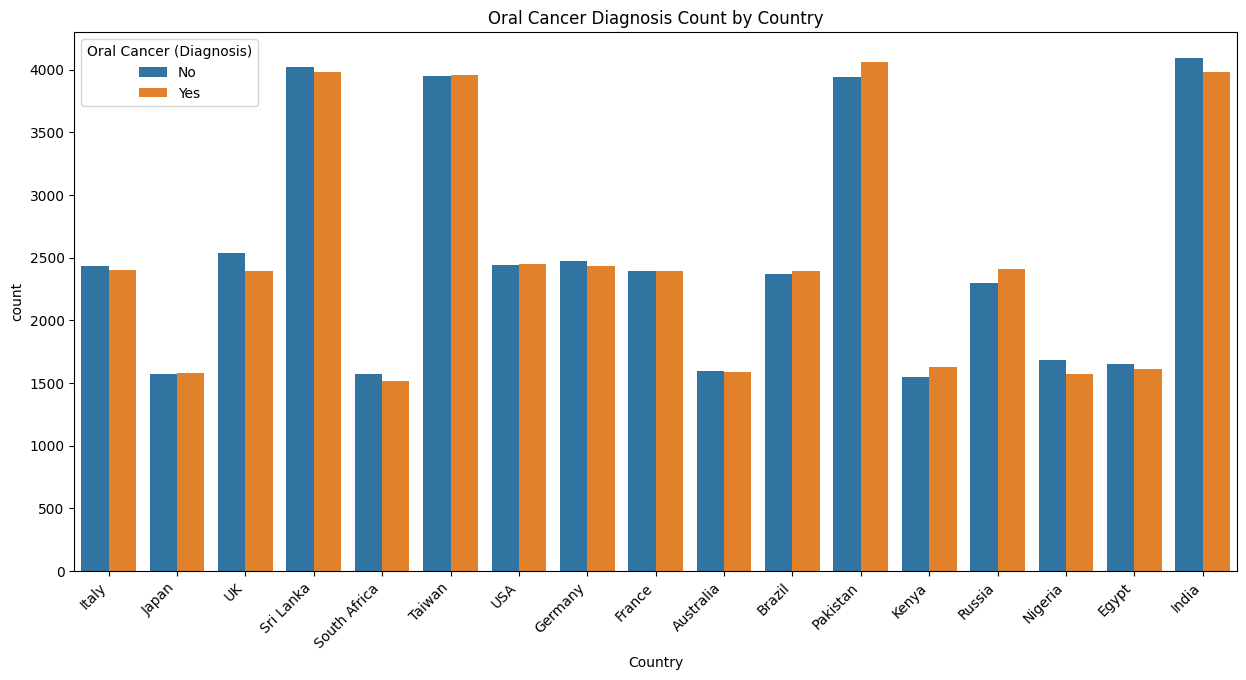

In [ ]:
plt.figure(figsize=(15, 7))
sns.countplot(data=df, x="Country", hue="Oral Cancer (Diagnosis)")
plt.xticks(rotation=45, ha='right')
plt.title('Oral Cancer Diagnosis Count by Country')
plt.show()

In [ ]:
df.columns

Index(['ID', 'Country', 'Age', 'Gender', 'Tobacco Use', 'Alcohol Consumption',
       'HPV Infection', 'Betel Quid Use', 'Chronic Sun Exposure',
       'Poor Oral Hygiene', 'Diet (Fruits & Vegetables Intake)',
       'Family History of Cancer', 'Compromised Immune System', 'Oral Lesions',
       'Unexplained Bleeding', 'Difficulty Swallowing',
       'White or Red Patches in Mouth', 'Tumor Size (cm)', 'Cancer Stage',
       'Treatment Type', 'Survival Rate (5-Year, %)',
       'Cost of Treatment (USD)', 'Economic Burden (Lost Workdays per Year)',
       'Early Diagnosis', 'Oral Cancer (Diagnosis)'],
      dtype='object')

In [ ]:
df['Oral Cancer (Diagnosis)'].value_counts()

,count
Oral Cancer (Diagnosis),
No,42573
Yes,42349


In [ ]:
df['Oral Cancer (Diagnosis)']=df['Oral Cancer (Diagnosis)'].str.strip()

In [ ]:
df.columns.str.strip()

Index(['ID', 'Country', 'Age', 'Gender', 'Tobacco Use', 'Alcohol Consumption',
       'HPV Infection', 'Betel Quid Use', 'Chronic Sun Exposure',
       'Poor Oral Hygiene', 'Diet (Fruits & Vegetables Intake)',
       'Family History of Cancer', 'Compromised Immune System', 'Oral Lesions',
       'Unexplained Bleeding', 'Difficulty Swallowing',
       'White or Red Patches in Mouth', 'Tumor Size (cm)', 'Cancer Stage',
       'Treatment Type', 'Survival Rate (5-Year, %)',
       'Cost of Treatment (USD)', 'Economic Burden (Lost Workdays per Year)',
       'Early Diagnosis', 'Oral Cancer (Diagnosis)'],
      dtype='object')

In [ ]:
df['Oral Cancer (Diagnosis)']

,Oral Cancer (Diagnosis)
0,No
1,Yes
2,Yes
3,No
4,Yes
...,...
84917,No
84918,No
84919,Yes
84920,No


# country

In [ ]:
#MIF step
from sklearn.model_selection import train_test_split

x=df.drop('Oral Cancer (Diagnosis)',axis=1)
y=df['Oral Cancer (Diagnosis)']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

In [ ]:
df["Country"].unique()

array(['Italy', 'Japan', 'UK', 'Sri Lanka', 'South Africa', 'Taiwan',
       'USA', 'Germany', 'France', 'Australia', 'Brazil', 'Pakistan',
       'Kenya', 'Russia', 'Nigeria', 'Egypt', 'India'], dtype=object)

In [ ]:
#because i got an error where it is telling that there are some integers in column
x_train['Country']=x_train['Country'].astype(str)
x_test['Country']=x_test['Country'].astype(str)

In [ ]:
x_train['Country'].unique()

array(['Australia', 'Sri Lanka', 'Brazil', 'UK', 'Germany', 'USA',
       'India', 'Japan', 'Taiwan', 'Egypt', 'France', 'Russia', 'Kenya',
       'Pakistan', 'Italy', 'South Africa', 'Nigeria'], dtype=object)

In [ ]:
x_test['Country'].unique()

array(['Nigeria', 'USA', 'Italy', 'France', 'Russia', 'UK', 'Taiwan',
       'Brazil', 'Sri Lanka', 'Pakistan', 'Kenya', 'Australia', 'Germany',
       'India', 'Egypt', 'South Africa', 'Japan'], dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
x_train['Country']=le.fit_transform(x_train["Country"])


In [ ]:
x_test['Country']=le.transform(x_test["Country"])

In [ ]:
from sklearn.feature_selection import mutual_info_classif

mi_score=mutual_info_classif(x_train[["Country"]],y_train)
print("MI SCORE FOR COUNTRY:",mi_score[0])

MI SCORE FOR COUNTRY: 0.0014051286168821342


# no run

In [ ]:
df.drop(columns=["Country"],inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84922 entries, 0 to 84921
Data columns (total 24 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   ID                                        84922 non-null  int64  
 1   Age                                       84922 non-null  int64  
 2   Gender                                    84922 non-null  object 
 3   Tobacco Use                               84922 non-null  object 
 4   Alcohol Consumption                       84922 non-null  object 
 5   HPV Infection                             84922 non-null  object 
 6   Betel Quid Use                            84922 non-null  object 
 7   Chronic Sun Exposure                      84922 non-null  object 
 8   Poor Oral Hygiene                         84922 non-null  object 
 9   Diet (Fruits & Vegetables Intake)         84922 non-null  object 
 10  Family History of Cancer          

In [ ]:
df.drop(columns=["ID"],inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84922 entries, 0 to 84921
Data columns (total 23 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Age                                       84922 non-null  int64  
 1   Gender                                    84922 non-null  object 
 2   Tobacco Use                               84922 non-null  object 
 3   Alcohol Consumption                       84922 non-null  object 
 4   HPV Infection                             84922 non-null  object 
 5   Betel Quid Use                            84922 non-null  object 
 6   Chronic Sun Exposure                      84922 non-null  object 
 7   Poor Oral Hygiene                         84922 non-null  object 
 8   Diet (Fruits & Vegetables Intake)         84922 non-null  object 
 9   Family History of Cancer                  84922 non-null  object 
 10  Compromised Immune System         

<Axes: xlabel='Tobacco Use', ylabel='count'>

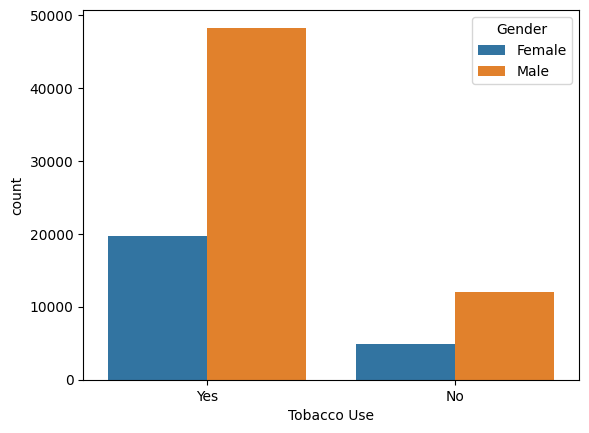

In [ ]:
sns.countplot(data=df,x='Tobacco Use',hue='Gender')

<Axes: xlabel='Age', ylabel='Density'>

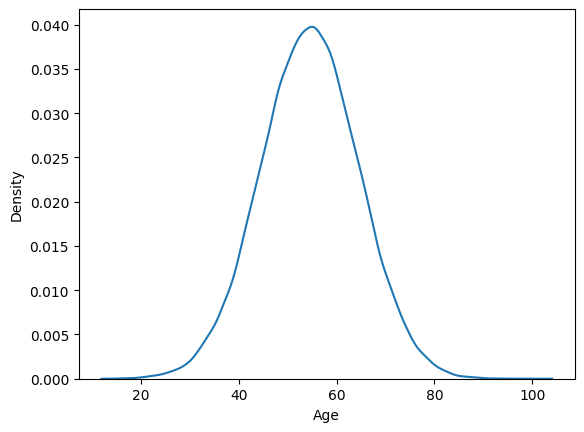

In [ ]:
sns.kdeplot(x='Age', data=df)

In [ ]:
categorical.remove("Country")

In [ ]:
for column in categorical:
  print("column and it's count with unique variables")
  print(df[column].value_counts())
  print("--------------------------------------------")


column and it's count with unique variables
Gender
Male      60351
Female    24571
Name: count, dtype: int64
--------------------------------------------
column and it's count with unique variables
Tobacco Use
Yes    67989
No     16933
Name: count, dtype: int64
--------------------------------------------
column and it's count with unique variables
Alcohol Consumption
Yes    50939
No     33983
Name: count, dtype: int64
--------------------------------------------
column and it's count with unique variables
HPV Infection
No     59525
Yes    25397
Name: count, dtype: int64
--------------------------------------------
column and it's count with unique variables
Betel Quid Use
No     60299
Yes    24623
Name: count, dtype: int64
--------------------------------------------
column and it's count with unique variables
Chronic Sun Exposure
No     68057
Yes    16865
Name: count, dtype: int64
--------------------------------------------
column and it's count with unique variables
Poor Oral Hygie

In [ ]:
numerical.remove('ID')

<Axes: xlabel='Age', ylabel='Count'>

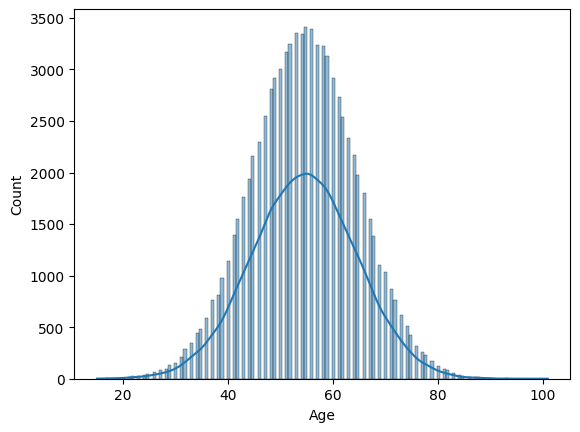

In [ ]:
#plots
sns.histplot(df['Age'],kde=True)

/tmp/ipython-input-1369121584.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df,x='Age',hue='Oral Cancer (Diagnosis)',shade=True)#doubt


<Axes: xlabel='Age', ylabel='Density'>

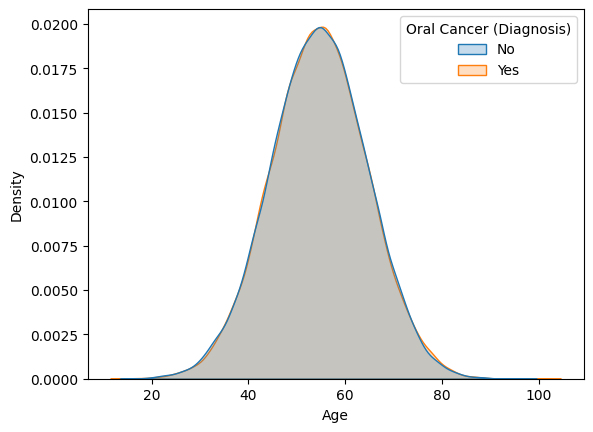

In [ ]:
sns.kdeplot(data=df,x='Age',hue='Oral Cancer (Diagnosis)',shade=True)#doubt

In [ ]:
numerical

['Age',
 'Tumor Size (cm)',
 'Cancer Stage',
 'Survival Rate (5-Year, %)',
 'Cost of Treatment (USD)',
 'Economic Burden (Lost Workdays per Year)']

<Axes: xlabel='Tumor Size (cm)', ylabel='Count'>

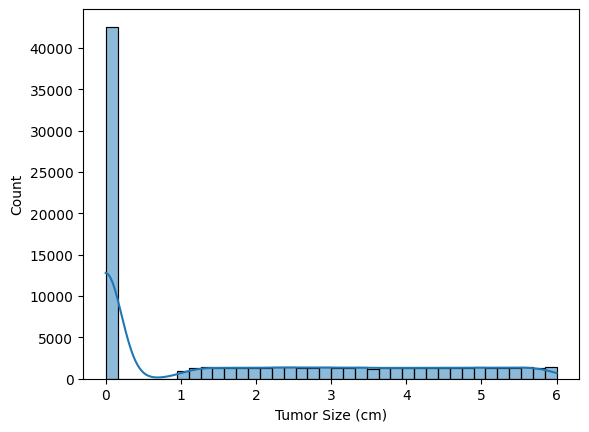

In [ ]:
sns.histplot(df['Tumor Size (cm)'],kde=True)

In [ ]:
df[df['Oral Cancer (Diagnosis)']=='No']['Tumor Size (cm)']

,Tumor Size (cm)
0,0.0
3,0.0
7,0.0
11,0.0
12,0.0
...,...
84916,0.0
84917,0.0
84918,0.0
84920,0.0


In [ ]:
df[df['Oral Cancer (Diagnosis)']=='Yes']['Tumor Size (cm)']

,Tumor Size (cm)
1,1.782186
2,3.523895
4,2.834789
5,1.692675
6,5.794843
...,...
84907,2.517119
84909,2.944852
84912,3.639770
84914,4.005084


/tmp/ipython-input-248891876.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df,x='Tumor Size (cm)',hue='Oral Cancer (Diagnosis)',shade=True)
/tmp/ipython-input-248891876.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df,x='Tumor Size (cm)',hue='Oral Cancer (Diagnosis)',shade=True)


<Axes: xlabel='Tumor Size (cm)', ylabel='Density'>

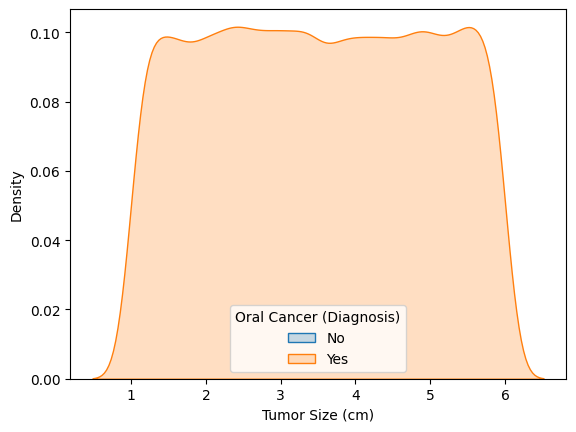

In [ ]:
sns.kdeplot(data=df,x='Tumor Size (cm)',hue='Oral Cancer (Diagnosis)',shade=True)

<Axes: xlabel='Cancer Stage', ylabel='count'>

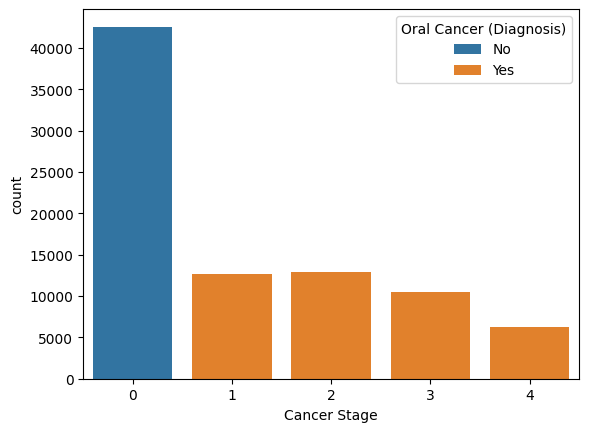

In [ ]:
sns.countplot(data=df, x='Cancer Stage', hue='Oral Cancer (Diagnosis)')

In [ ]:
numerical

['Age',
 'Tumor Size (cm)',
 'Cancer Stage',
 'Survival Rate (5-Year, %)',
 'Cost of Treatment (USD)',
 'Economic Burden (Lost Workdays per Year)']

<Axes: xlabel='Survival Rate (5-Year, %)', ylabel='Count'>

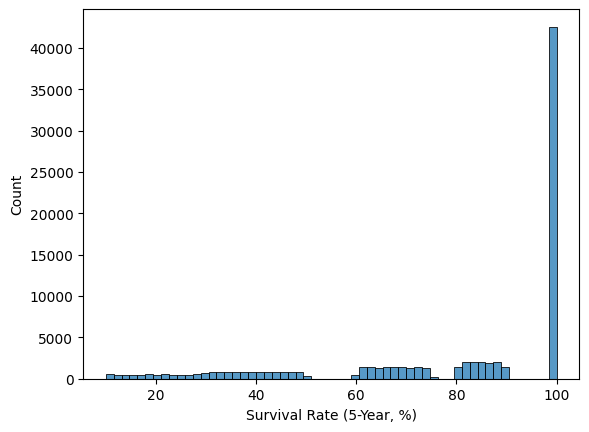

In [ ]:
sns.histplot(data=df,x="Survival Rate (5-Year, %)")

/tmp/ipython-input-680319061.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df,x="Survival Rate (5-Year, %)",hue='Oral Cancer (Diagnosis)',shade=True)
/tmp/ipython-input-680319061.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df,x="Survival Rate (5-Year, %)",hue='Oral Cancer (Diagnosis)',shade=True)


<Axes: xlabel='Survival Rate (5-Year, %)', ylabel='Density'>

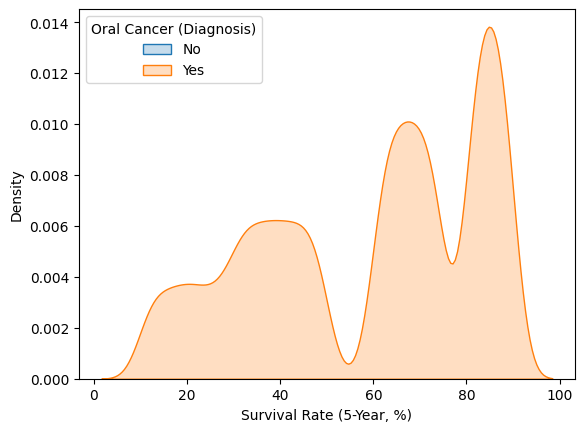

In [ ]:
sns.kdeplot(data=df,x="Survival Rate (5-Year, %)",hue='Oral Cancer (Diagnosis)',shade=True)

In [ ]:
df[df["Oral Cancer (Diagnosis)"]=='No']["Survival Rate (5-Year, %)"].var()

0.0

In [ ]:
df[df["Oral Cancer (Diagnosis)"]=='No']["Survival Rate (5-Year, %)"]

,"Survival Rate (5-Year, %)"
0,100.0
3,100.0
7,100.0
11,100.0
12,100.0
...,...
84916,100.0
84917,100.0
84918,100.0
84920,100.0


<Axes: xlabel='Cost of Treatment (USD)', ylabel='Density'>

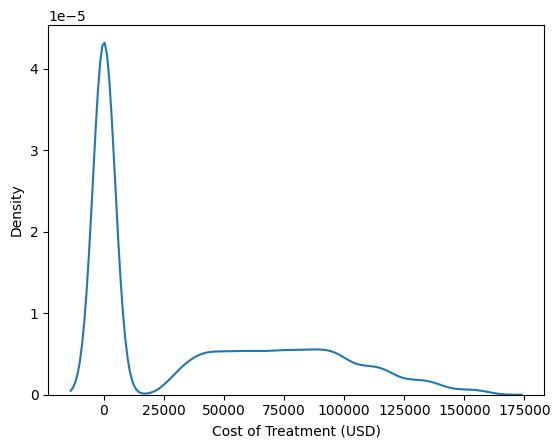

In [ ]:
sns.kdeplot(data=df,x='Cost of Treatment (USD)')

/tmp/ipython-input-811744129.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df,x='Cost of Treatment (USD)',hue='Oral Cancer (Diagnosis)',shade=True)
/tmp/ipython-input-811744129.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df,x='Cost of Treatment (USD)',hue='Oral Cancer (Diagnosis)',shade=True)


<Axes: xlabel='Cost of Treatment (USD)', ylabel='Density'>

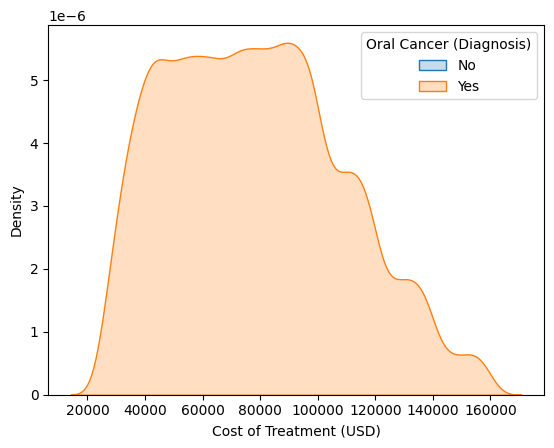

In [ ]:
sns.kdeplot(data=df,x='Cost of Treatment (USD)',hue='Oral Cancer (Diagnosis)',shade=True)

In [ ]:
df[df["Oral Cancer (Diagnosis)"]=='No']["Cost of Treatment (USD)"].var()

0.0

In [ ]:
df[df["Oral Cancer (Diagnosis)"]=='No']["Cost of Treatment (USD)"]

,Cost of Treatment (USD)
0,0.0
3,0.0
7,0.0
11,0.0
12,0.0
...,...
84916,0.0
84917,0.0
84918,0.0
84920,0.0


In [ ]:
numerical

['Age',
 'Tumor Size (cm)',
 'Cancer Stage',
 'Survival Rate (5-Year, %)',
 'Cost of Treatment (USD)',
 'Economic Burden (Lost Workdays per Year)']

In [ ]:
for column in categorical:
  print("column and it's count with unique variables")
  print(df[column].value_counts())
  print("--------------------------------------------")


column and it's count with unique variables
Gender
Male      60351
Female    24571
Name: count, dtype: int64
--------------------------------------------
column and it's count with unique variables
Tobacco Use
Yes    67989
No     16933
Name: count, dtype: int64
--------------------------------------------
column and it's count with unique variables
Alcohol Consumption
Yes    50939
No     33983
Name: count, dtype: int64
--------------------------------------------
column and it's count with unique variables
HPV Infection
No     59525
Yes    25397
Name: count, dtype: int64
--------------------------------------------
column and it's count with unique variables
Betel Quid Use
No     60299
Yes    24623
Name: count, dtype: int64
--------------------------------------------
column and it's count with unique variables
Chronic Sun Exposure
No     68057
Yes    16865
Name: count, dtype: int64
--------------------------------------------
column and it's count with unique variables
Poor Oral Hygie

In [ ]:
df['Gender']=df['Gender'].map({'Male':1,'Female':0})

In [ ]:
df['Gender']=df['Gender'].astype(int)

In [ ]:
df['Betel Quid Use']=df['Betel Quid Use'].map({'Yes':1,'No':0})

In [ ]:
df['Tobacco Use']=df['Tobacco Use'].map({'Yes':1,'No':0})

In [ ]:
df['Tobacco Use']=df['Tobacco Use'].astype(int)

In [ ]:
df['Alcohol Consumption']=df['Alcohol Consumption'].map({'Yes':1,'No':0})

In [ ]:
df['Alcohol Consumption']=df['Alcohol Consumption'].astype(int)

In [ ]:
df['Betel Quid Use']=df['Betel Quid Use'].astype(int)

<Axes: xlabel='Tobacco Use', ylabel='count'>

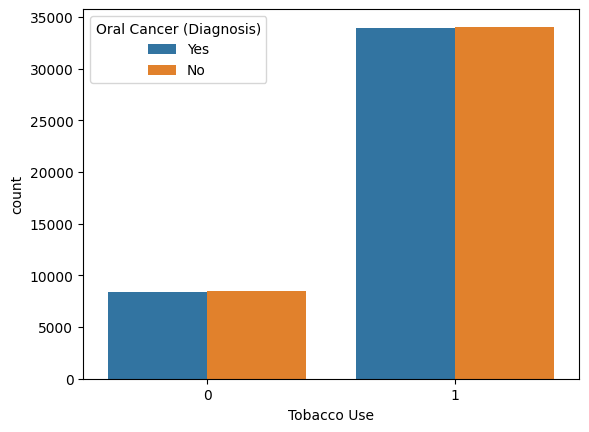

In [ ]:
sns.countplot(data=df,x='Tobacco Use',hue='Oral Cancer (Diagnosis)')

In [ ]:
numerical=[feature for feature in df.columns if df[feature].dtype != "O"]

In [ ]:
categorical=[feature for feature in df.columns if df[feature].dtype == "O"]

In [ ]:
numerical

['Age',
 'Gender',
 'Tobacco Use',
 'Alcohol Consumption',
 'Betel Quid Use',
 'Tumor Size (cm)',
 'Cancer Stage',
 'Survival Rate (5-Year, %)',
 'Cost of Treatment (USD)',
 'Economic Burden (Lost Workdays per Year)']

In [ ]:
categorical

['HPV Infection',
 'Chronic Sun Exposure',
 'Poor Oral Hygiene',
 'Diet (Fruits & Vegetables Intake)',
 'Family History of Cancer',
 'Compromised Immune System',
 'Oral Lesions',
 'Unexplained Bleeding',
 'Difficulty Swallowing',
 'White or Red Patches in Mouth',
 'Treatment Type',
 'Early Diagnosis',
 'Oral Cancer (Diagnosis)']

In [ ]:
df['Oral Lesions']=df['Oral Lesions'].map({'Yes':1,'No':0})
df['Oral Lesions']=df['Oral Lesions'].astype(int)

In [ ]:
df['Unexplained Bleeding']=df['Unexplained Bleeding'].map({'Yes':1,'No':0})
df['Unexplained Bleeding']=df['Unexplained Bleeding'].astype(int)

In [ ]:
df['Difficulty Swallowing']=df['Difficulty Swallowing'].map({'Yes':1,'No':0})
df['Difficulty Swallowing']=df['Difficulty Swallowing'].astype(int)

In [ ]:
df['White or Red Patches in Mouth']=df['White or Red Patches in Mouth'].map({'Yes':1,'No':0})
df['White or Red Patches in Mouth']=df['White or Red Patches in Mouth'].astype(int)

<Axes: xlabel='Treatment Type', ylabel='count'>

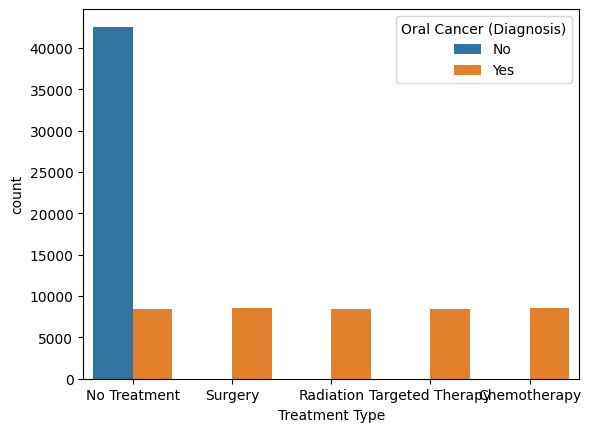

In [ ]:
sns.countplot(data=df,x='Treatment Type',hue='Oral Cancer (Diagnosis)')

In [ ]:
df['Early Diagnosis']=df['Early Diagnosis'].map({'Yes':1,'No':0})
df['Early Diagnosis']=df['Early Diagnosis'].astype(int)

In [ ]:
df['Oral Cancer (Diagnosis)']=df['Oral Cancer (Diagnosis)'].map({'Yes':1,'No':0})
df['Oral Cancer (Diagnosis)']=df['Oral Cancer (Diagnosis)'].astype(int)

In [ ]:
df['Compromised Immune System']=df['Compromised Immune System'].map({'Yes':1,'No':0})

In [ ]:
df['Compromised Immune System']=df['Compromised Immune System'].astype(int)

<Axes: xlabel='Compromised Immune System', ylabel='count'>

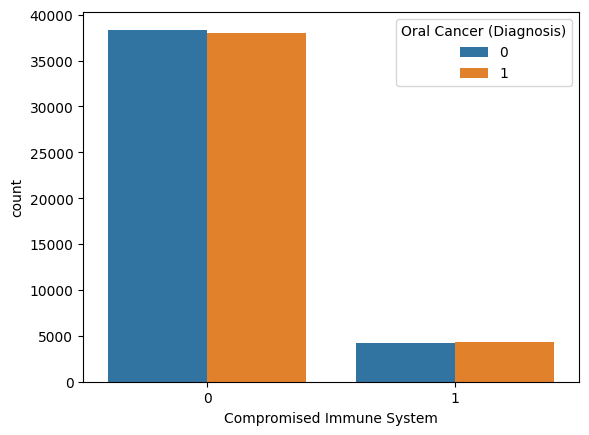

In [ ]:
sns.countplot(data=df,x='Compromised Immune System',hue='Oral Cancer (Diagnosis)')

In [ ]:
df['Family History of Cancer']=df['Family History of Cancer'].map({'Yes':1,'No':0})
df['Family History of Cancer']=df['Family History of Cancer'].astype(int)

<Axes: xlabel='Family History of Cancer', ylabel='count'>

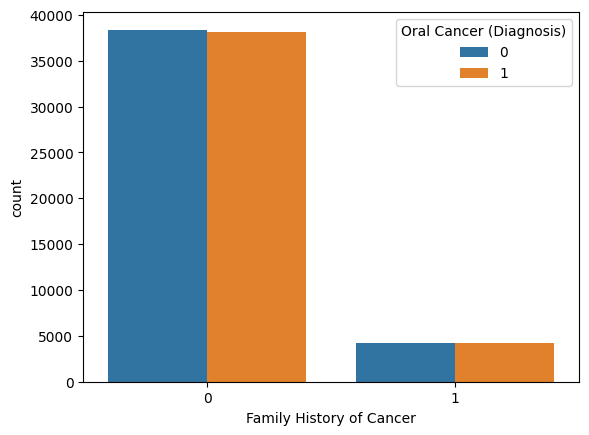

In [ ]:
sns.countplot(data=df,x='Family History of Cancer',hue='Oral Cancer (Diagnosis)')

In [ ]:
df['Poor Oral Hygiene']=df['Poor Oral Hygiene'].map({'Yes':1,'No':0})
df['Poor Oral Hygiene']=df['Poor Oral Hygiene'].astype(int)

In [ ]:
df['Chronic Sun Exposure']=df['Chronic Sun Exposure'].map({'Yes':1,'No':0})

In [ ]:
df['Chronic Sun Exposure']=df['Chronic Sun Exposure'].astype(int)

<Axes: xlabel='Chronic Sun Exposure', ylabel='count'>

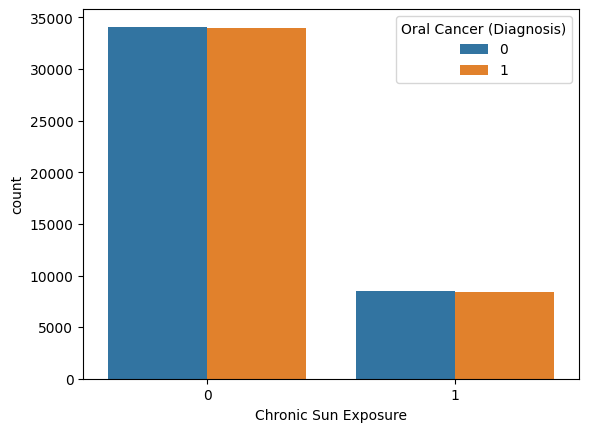

In [ ]:
sns.countplot(data=df,x='Chronic Sun Exposure',hue='Oral Cancer (Diagnosis)')

In [ ]:
df['HPV Infection']=df['HPV Infection'].map({"Yes":1,"No":0})
df['HPV Infection']=df['HPV Infection'].astype(int)

<Axes: xlabel='HPV Infection', ylabel='count'>

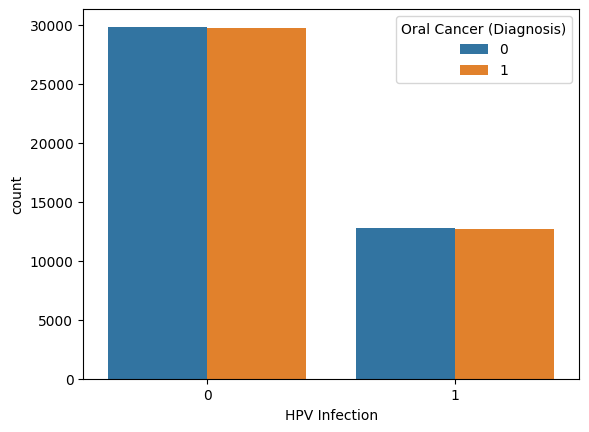

In [ ]:
sns.countplot(data=df,x='HPV Infection',hue='Oral Cancer (Diagnosis)')

<Axes: xlabel='Gender', ylabel='count'>

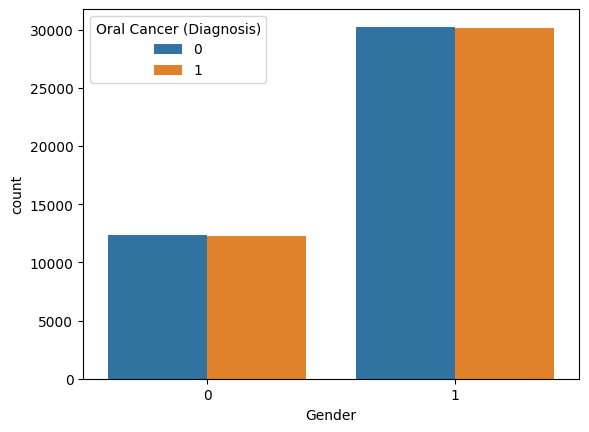

In [ ]:
sns.countplot(data=df,x='Gender',hue='Oral Cancer (Diagnosis)')

<Axes: xlabel='Oral Cancer (Diagnosis)', ylabel='Tobacco Use'>

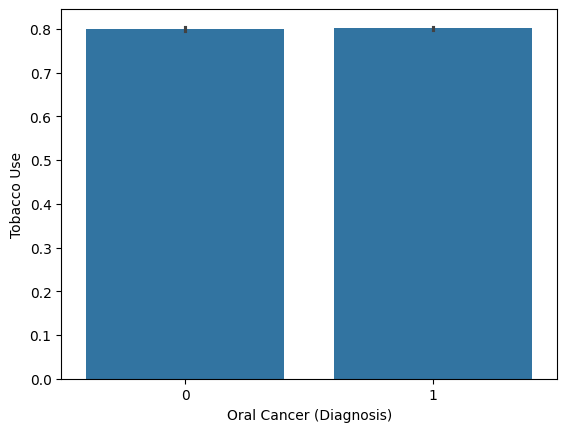

In [ ]:
sns.barplot(data=df,y='Tobacco Use',x='Oral Cancer (Diagnosis)')

<Axes: xlabel='Betel Quid Use', ylabel='count'>

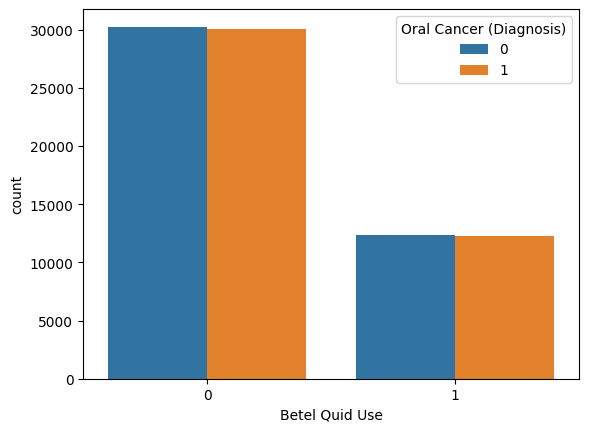

In [ ]:
sns.countplot(data=df,x='Betel Quid Use',hue='Oral Cancer (Diagnosis)')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84922 entries, 0 to 84921
Data columns (total 23 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Age                                       84922 non-null  int64  
 1   Gender                                    84922 non-null  int64  
 2   Tobacco Use                               84922 non-null  int64  
 3   Alcohol Consumption                       84922 non-null  int64  
 4   HPV Infection                             84922 non-null  int64  
 5   Betel Quid Use                            84922 non-null  int64  
 6   Chronic Sun Exposure                      84922 non-null  int64  
 7   Poor Oral Hygiene                         84922 non-null  int64  
 8   Diet (Fruits & Vegetables Intake)         84922 non-null  object 
 9   Family History of Cancer                  84922 non-null  int64  
 10  Compromised Immune System         

In [ ]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

# 1. Select only numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 2. Remove the target column from the numerical list
target = "Oral Cancer (Diagnosis)"
if target in numerical_cols:
    numerical_cols.remove(target)

# 3. Define X and y
X = df[numerical_cols]
y = df[target]    # Already 0/1 → perfect for MI

# 4. Calculate MI scores
mi_scores = mutual_info_classif(X, y, random_state=42)

# 5. Prepare a table to view scores
mi_df = pd.DataFrame({
    'Feature': numerical_cols,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

# 6. Display
print(mi_df)


                                     Feature  MI_Score
16                 Survival Rate (5-Year, %)  0.698048
15                              Cancer Stage  0.695193
18  Economic Burden (Lost Workdays per Year)  0.693214
14                           Tumor Size (cm)  0.693150
17                   Cost of Treatment (USD)  0.693150
2                                Tobacco Use  0.009220
7                          Poor Oral Hygiene  0.008617
3                        Alcohol Consumption  0.007605
19                           Early Diagnosis  0.007399
1                                     Gender  0.007276
4                              HPV Infection  0.004687
11                      Unexplained Bleeding  0.003819
8                   Family History of Cancer  0.003538
13             White or Red Patches in Mouth  0.003273
10                              Oral Lesions  0.002158
6                       Chronic Sun Exposure  0.002107
5                             Betel Quid Use  0.001725
9         

In [ ]:
counts=df['Oral Cancer (Diagnosis)'].value_counts()

In [ ]:
counts

,count
Oral Cancer (Diagnosis),
0,42573
1,42349


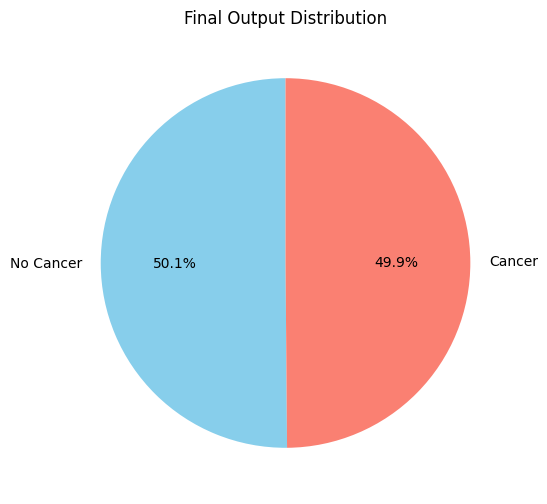

In [ ]:
plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=['No Cancer', 'Cancer'],
    autopct='%1.1f%%',
    colors=['skyblue', 'salmon'],
    startangle=90
)
plt.title("Final Output Distribution")
plt.show()


In [ ]:
df.drop(columns=['Survival Rate (5-Year, %)','Cancer Stage','Economic Burden (Lost Workdays per Year)','Tumor Size (cm)','Cost of Treatment (USD)','Treatment Type'],inplace=True)

In [ ]:
df.columns

Index(['Age', 'Gender', 'Tobacco Use', 'Alcohol Consumption', 'HPV Infection',
       'Betel Quid Use', 'Chronic Sun Exposure', 'Poor Oral Hygiene',
       'Diet (Fruits & Vegetables Intake)', 'Family History of Cancer',
       'Compromised Immune System', 'Oral Lesions', 'Unexplained Bleeding',
       'Difficulty Swallowing', 'White or Red Patches in Mouth',
       'Early Diagnosis', 'Oral Cancer (Diagnosis)'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
x=df.drop(['Oral Cancer (Diagnosis)'],axis=1)
y=df['Oral Cancer (Diagnosis)']

In [ ]:
x.head()

,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,Diet (Fruits & Vegetables Intake),Family History of Cancer,Compromised Immune System,Oral Lesions,Unexplained Bleeding,Difficulty Swallowing,White or Red Patches in Mouth,Early Diagnosis
0,36,0,1,1,1,0,0,1,Low,0,0,0,0,0,0,0
1,64,1,1,1,1,0,1,1,High,0,0,0,1,0,0,0
2,37,0,0,1,0,0,1,1,Moderate,0,0,0,0,0,1,1
3,55,1,1,1,0,1,0,1,Moderate,0,0,1,0,0,0,1
4,68,1,0,0,0,0,0,1,High,0,0,0,0,0,0,0


In [ ]:
y.value_counts()

,count
Oral Cancer (Diagnosis),
0,42573
1,42349


In [ ]:
# separate dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((67937, 16), (16985, 16))

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84922 entries, 0 to 84921
Data columns (total 16 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Age                                84922 non-null  int64 
 1   Gender                             84922 non-null  int64 
 2   Tobacco Use                        84922 non-null  int64 
 3   Alcohol Consumption                84922 non-null  int64 
 4   HPV Infection                      84922 non-null  int64 
 5   Betel Quid Use                     84922 non-null  int64 
 6   Chronic Sun Exposure               84922 non-null  int64 
 7   Poor Oral Hygiene                  84922 non-null  int64 
 8   Diet (Fruits & Vegetables Intake)  84922 non-null  object
 9   Family History of Cancer           84922 non-null  int64 
 10  Compromised Immune System          84922 non-null  int64 
 11  Oral Lesions                       84922 non-null  int64 
 12  Unex

In [ ]:
# Create Column Transformer with 3 types of transformers
cat_features = x.select_dtypes(include="object").columns
num_features = x.select_dtypes(exclude="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    [
         ("OneHotEncoder", oh_transformer, cat_features),
          ("StandardScaler", numeric_transformer, num_features)
    ]
)

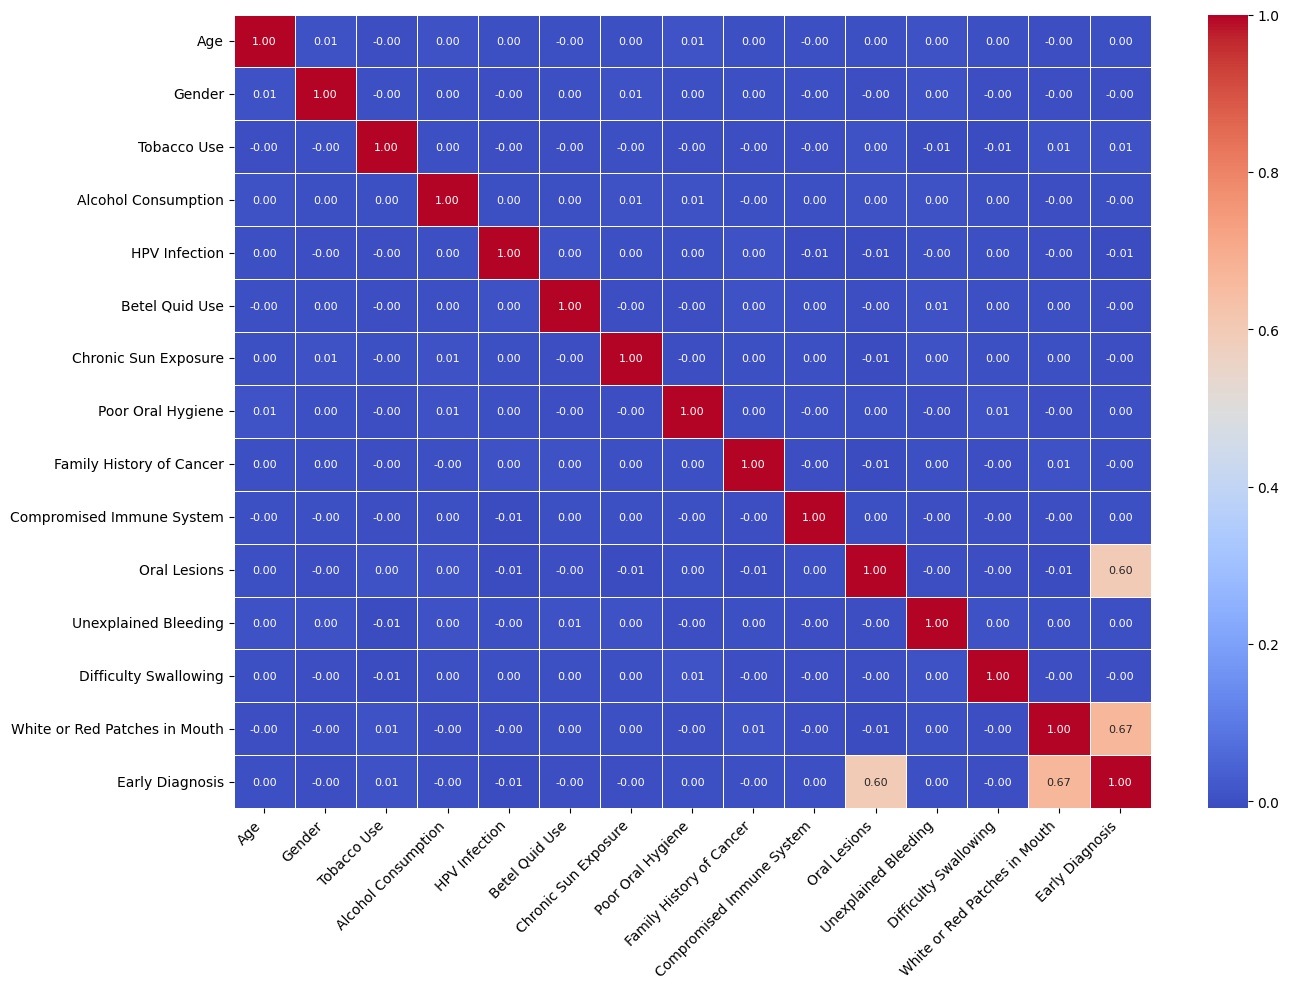

In [ ]:
plt.figure(figsize=(14, 10))  # Bigger figure

sns.heatmap(
    df[num_features].corr(),
    annot=True,        # numbers
    fmt=".2f",         # 2 decimals
    cmap="coolwarm",   # better colors
    linewidths=0.5,    # small gaps
    annot_kws={"size": 8},  # increase or decrease number size
)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
cat_features

Index(['Diet (Fruits & Vegetables Intake)'], dtype='object')

In [ ]:
preprocessor

ColumnTransformer(transformers=[('OneHotEncoder', OneHotEncoder(drop='first'),
                                 Index(['Diet (Fruits & Vegetables Intake)'], dtype='object')),
                                ('StandardScaler', StandardScaler(),
                                 Index(['Age', 'Gender', 'Tobacco Use', 'Alcohol Consumption', 'HPV Infection',
       'Betel Quid Use', 'Chronic Sun Exposure', 'Poor Oral Hygiene',
       'Family History of Cancer', 'Compromised Immune System', 'Oral Lesions',
       'Unexplained Bleeding', 'Difficulty Swallowing',
       'White or Red Patches in Mouth', 'Early Diagnosis'],
      dtype='object'))])

In [ ]:
## applying Trnsformation in training(fit_transform)
X_train=preprocessor.fit_transform(X_train)

In [ ]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,0.0,0.0,-1.350284,0.638171,0.497644,0.814325,1.522513,-0.640136,-0.498818,-0.996928,-0.332168,2.989669,-0.654284,-0.500727,-0.578500,-0.736033,-1.099436
1,1.0,0.0,-0.151130,0.638171,0.497644,-1.228011,-0.656809,-0.640136,-0.498818,1.003081,-0.332168,2.989669,-0.654284,-0.500727,-0.578500,-0.736033,-1.099436
2,1.0,0.0,0.748234,-1.566978,0.497644,0.814325,-0.656809,1.562169,2.004741,-0.996928,-0.332168,2.989669,-0.654284,-0.500727,-0.578500,-0.736033,-1.099436
3,1.0,0.0,0.848164,0.638171,0.497644,-1.228011,1.522513,-0.640136,-0.498818,1.003081,-0.332168,-0.334485,-0.654284,1.997098,1.728607,1.358634,0.909558
4,0.0,0.0,2.147247,-1.566978,0.497644,-1.228011,-0.656809,-0.640136,-0.498818,-0.996928,-0.332168,2.989669,-0.654284,-0.500727,-0.578500,1.358634,0.909558
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67932,0.0,0.0,-1.150425,0.638171,-2.009470,0.814325,-0.656809,1.562169,-0.498818,1.003081,-0.332168,-0.334485,-0.654284,-0.500727,-0.578500,1.358634,0.909558
67933,0.0,0.0,1.347811,-1.566978,0.497644,0.814325,1.522513,-0.640136,-0.498818,-0.996928,-0.332168,-0.334485,-0.654284,-0.500727,-0.578500,1.358634,0.909558
67934,0.0,1.0,-0.051201,0.638171,0.497644,0.814325,1.522513,-0.640136,-0.498818,1.003081,-0.332168,2.989669,1.528388,-0.500727,-0.578500,-0.736033,0.909558
67935,0.0,0.0,0.048728,-1.566978,0.497644,0.814325,-0.656809,-0.640136,-0.498818,-0.996928,-0.332168,-0.334485,-0.654284,-0.500727,-0.578500,1.358634,0.909558


In [ ]:
## apply tansformation on test(transform)
X_test=preprocessor.transform(X_test)

In [ ]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,0.0,0.0,-1.350284,0.638171,0.497644,0.814325,1.522513,-0.640136,-0.498818,-0.996928,-0.332168,2.989669,-0.654284,-0.500727,-0.578500,-0.736033,-1.099436
1,1.0,0.0,-0.151130,0.638171,0.497644,-1.228011,-0.656809,-0.640136,-0.498818,1.003081,-0.332168,2.989669,-0.654284,-0.500727,-0.578500,-0.736033,-1.099436
2,1.0,0.0,0.748234,-1.566978,0.497644,0.814325,-0.656809,1.562169,2.004741,-0.996928,-0.332168,2.989669,-0.654284,-0.500727,-0.578500,-0.736033,-1.099436
3,1.0,0.0,0.848164,0.638171,0.497644,-1.228011,1.522513,-0.640136,-0.498818,1.003081,-0.332168,-0.334485,-0.654284,1.997098,1.728607,1.358634,0.909558
4,0.0,0.0,2.147247,-1.566978,0.497644,-1.228011,-0.656809,-0.640136,-0.498818,-0.996928,-0.332168,2.989669,-0.654284,-0.500727,-0.578500,1.358634,0.909558
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67932,0.0,0.0,-1.150425,0.638171,-2.009470,0.814325,-0.656809,1.562169,-0.498818,1.003081,-0.332168,-0.334485,-0.654284,-0.500727,-0.578500,1.358634,0.909558
67933,0.0,0.0,1.347811,-1.566978,0.497644,0.814325,1.522513,-0.640136,-0.498818,-0.996928,-0.332168,-0.334485,-0.654284,-0.500727,-0.578500,1.358634,0.909558
67934,0.0,1.0,-0.051201,0.638171,0.497644,0.814325,1.522513,-0.640136,-0.498818,1.003081,-0.332168,2.989669,1.528388,-0.500727,-0.578500,-0.736033,0.909558
67935,0.0,0.0,0.048728,-1.566978,0.497644,0.814325,-0.656809,-0.640136,-0.498818,-0.996928,-0.332168,-0.334485,-0.654284,-0.500727,-0.578500,1.358634,0.909558


In [ ]:
!pip install xgboost

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve

In [ ]:
models={
    "Logisitic Regression":LogisticRegression(),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(),
    "Gradient Boost":GradientBoostingClassifier(),
    "Adaboost":AdaBoostClassifier(),
    "Xgboost":XGBClassifier()
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


    print(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))

    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))



    print('----------------------------------')

    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))


    print('='*35)
    print('\n')

Logisitic Regression
Model performance for Training set
- Accuracy: 0.5056
- F1 score: 0.5048
- Precision: 0.5053
- Recall: 0.4662
- Roc Auc Score: 0.5055
----------------------------------
Model performance for Test set
- Accuracy: 0.4978
- F1 score: 0.4971
- Precision: 0.4933
- Recall: 0.4603
- Roc Auc Score: 0.4975


Decision Tree
Model performance for Training set
- Accuracy: 0.8660
- F1 score: 0.8654
- Precision: 0.9183
- Recall: 0.8030
- Roc Auc Score: 0.8659
----------------------------------
Model performance for Test set
- Accuracy: 0.4963
- F1 score: 0.4949
- Precision: 0.4914
- Recall: 0.4432
- Roc Auc Score: 0.4959


Random Forest
Model performance for Training set
- Accuracy: 0.8659
- F1 score: 0.8659
- Precision: 0.8672
- Recall: 0.8637
- Roc Auc Score: 0.8659
----------------------------------
Model performance for Test set
- Accuracy: 0.5003
- F1 score: 0.5002
- Precision: 0.4962
- Recall: 0.4918
- Roc Auc Score: 0.5002


Gradient Boost
Model performance for Training se

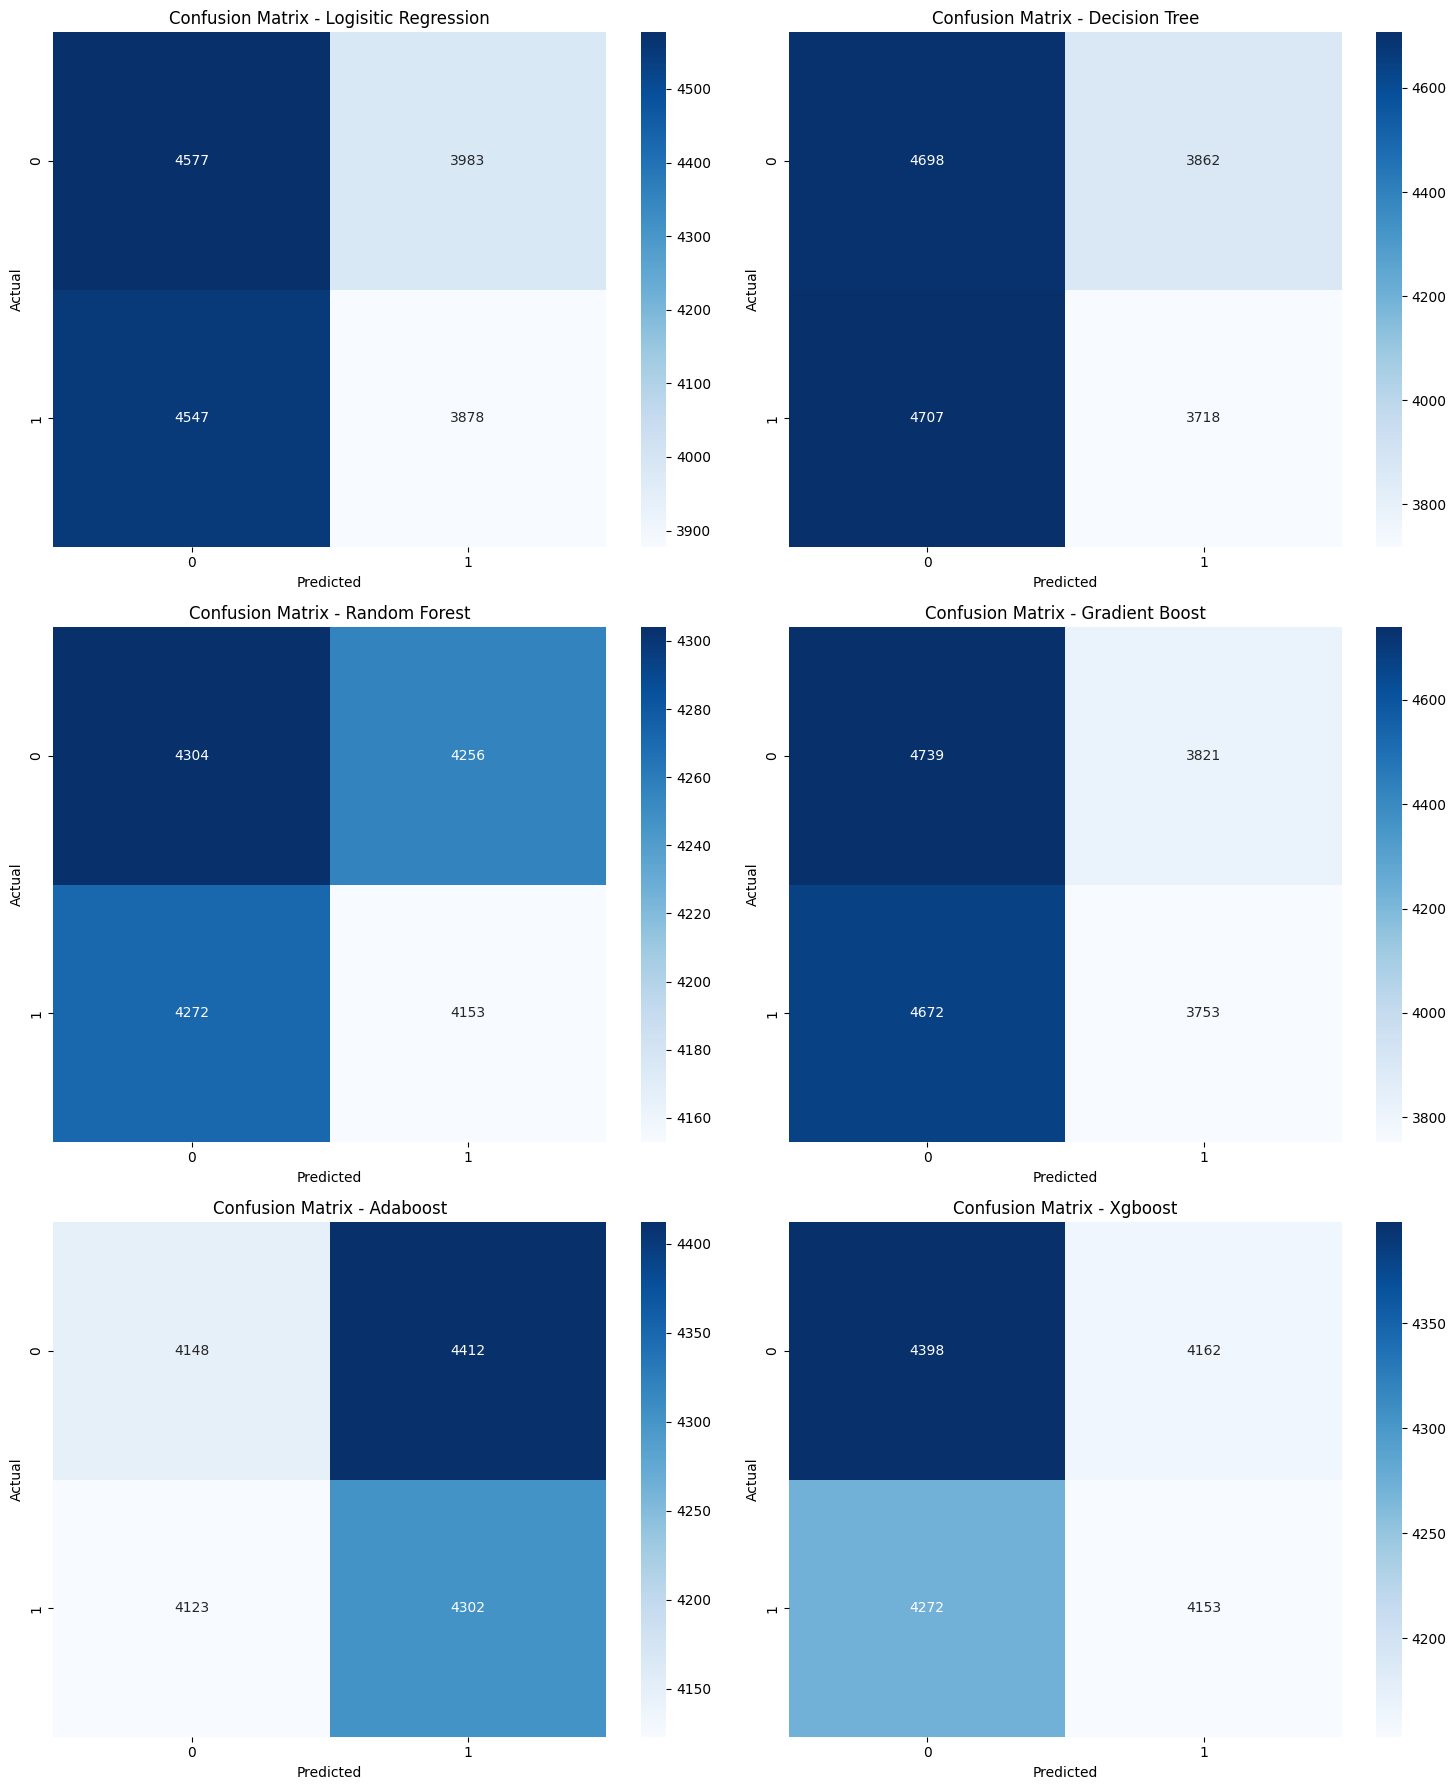

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

models_list = list(models.values())
model_names = list(models.keys())

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

for i, (name, model) in enumerate(zip(model_names, models_list)):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", ax=axes[i])
    axes[i].set_title(f"Confusion Matrix - {name}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

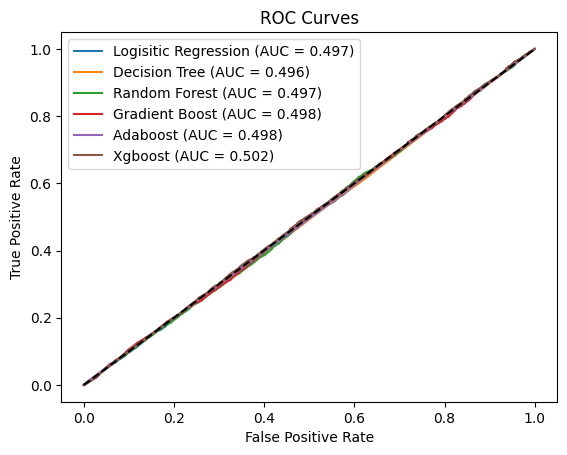

In [ ]:
from sklearn.metrics import roc_curve, auc

for name, model in zip(model_names, models_list):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc_score = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


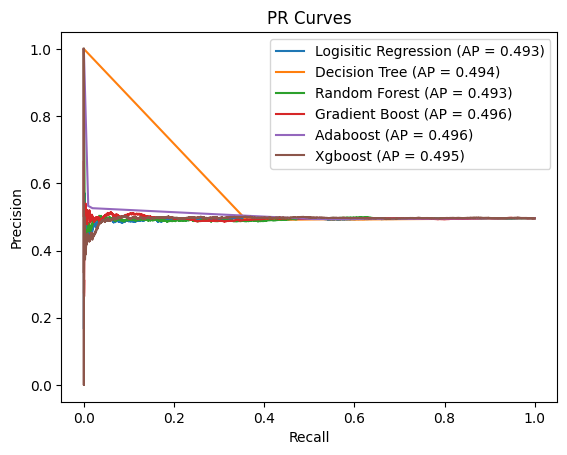

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

for name, model in zip(model_names, models_list):
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)

    plt.plot(recall, precision, label=f"{name} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curves")
plt.legend()
plt.show()


In [ ]:
results = {
    "Model": [],
    "Accuracy": [],
    "F1 Score": [],
    "Precision": [],
    "Recall": [],
    "ROC-AUC": []
}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_test_pred = model.predict(X_test)

    results["Model"].append(name)
    results["Accuracy"].append(accuracy_score(y_test, y_test_pred))
    results["F1 Score"].append(f1_score(y_test, y_test_pred, average='weighted'))
    results["Precision"].append(precision_score(y_test, y_test_pred))
    results["Recall"].append(recall_score(y_test, y_test_pred))
    results["ROC-AUC"].append(roc_auc_score(y_test, y_test_pred))


In [ ]:
import pandas as pd

df_results = pd.DataFrame(results)
print(df_results)


                  Model  Accuracy  F1 Score  Precision    Recall   ROC-AUC
0  Logisitic Regression  0.497792  0.497105   0.493321  0.460297  0.497496
1         Decision Tree  0.495496  0.494043   0.490501  0.441306  0.495069
2         Random Forest  0.497910  0.497906   0.493876  0.492938  0.497871
3        Gradient Boost  0.499971  0.498511   0.495511  0.445460  0.499541
4              Adaboost  0.497498  0.497420   0.493688  0.510623  0.497601
5               Xgboost  0.503444  0.503398   0.499459  0.492938  0.503361


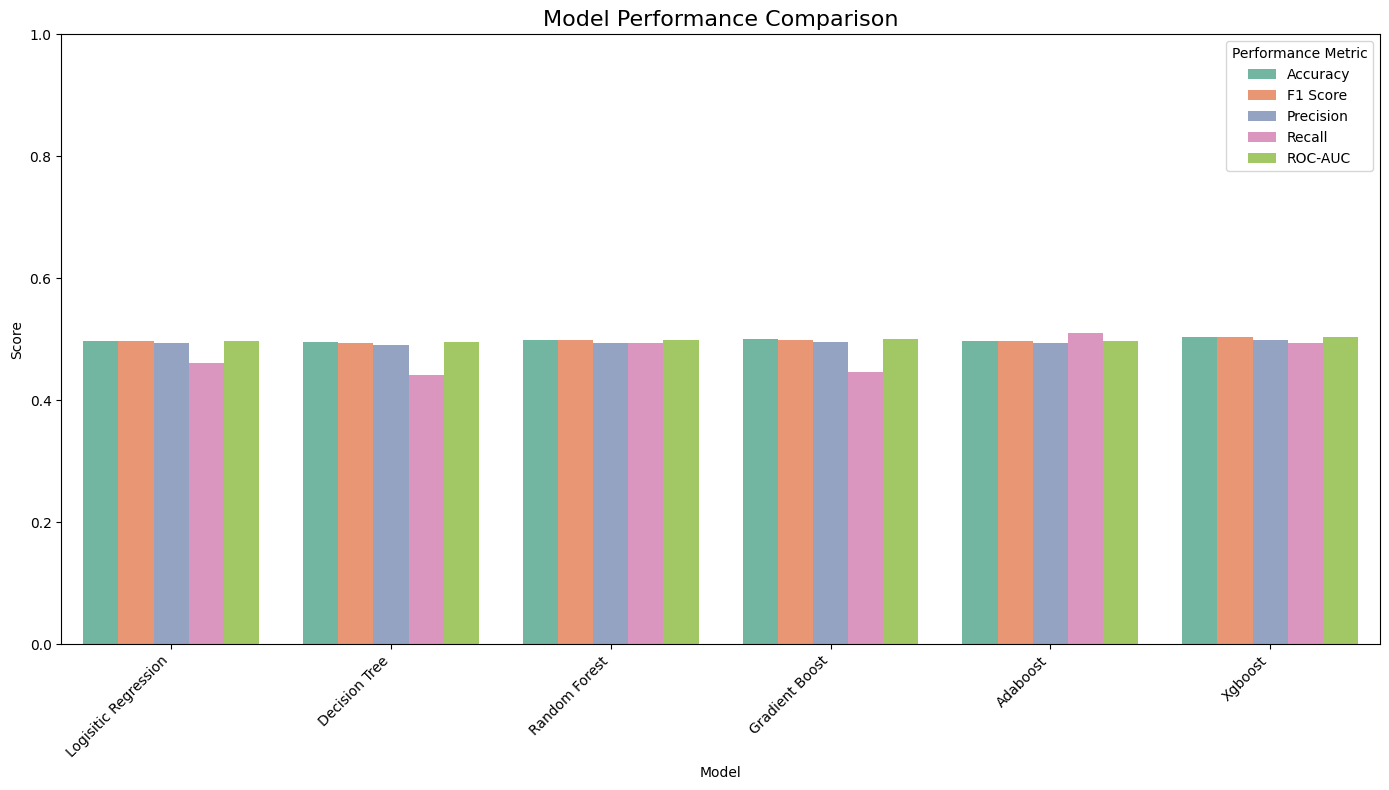

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
df_long = df_results.melt(id_vars="Model", var_name="Metric", value_name="Score")

sns.barplot(
    data=df_long,
    x="Model",
    y="Score",
    hue="Metric",
    palette="Set2"
)

plt.title("Model Performance Comparison", fontsize=16)
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)  # Scores are between 0 and 1
plt.legend(title="Performance Metric")
plt.tight_layout()
plt.show()


KeyboardInterrupt: 